## ``` 📞 Customer Churn Prediction using Machine Learning```

## Problem Statement

Customer churn is one of the most critical challenges faced by subscription-based businesses. It refers to the situation where customers stop using a company's products or services.

Customer acquisition is significantly more expensive than customer retention. Therefore, identifying customers who are likely to churn allows businesses to take proactive actions such as offering personalized discounts, improving customer support, or introducing loyalty programs.

The objective of this project is to build a Machine Learning model that predicts whether a customer is likely to churn based on customer demographics, subscription details, service usage, payment behavior, and customer interaction history.

The trained model can help businesses reduce customer loss, improve retention strategies, and maximize long-term revenue.

## Business Problem

Every business wants to retain its customers because losing existing customers directly impacts revenue and profitability.

The company wants to answer the following business questions:

- Which customers are likely to churn?
- What factors influence customer churn?
- Which customers should receive retention offers?
- How can customer satisfaction be improved?
- Which customer segments are at higher risk of leaving?

## Machine Learning Problem

This is a **Supervised Machine Learning** problem because historical customer data along with churn labels are available in the training dataset.

It is specifically a **Binary Classification** problem since the target variable contains only two classes:

- Churn = 1 (Customer Left)
- Churn = 0 (Customer Stayed)

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Understanding the data

In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/train.csv")

In [47]:
print("Train Shape :", df.shape)

Train Shape : (64374, 12)


In [48]:
from IPython.display import display
import pandas as pd

print('='*60)
print('📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY')
print('='*60)

print('\n📌 Dataset Shape')
print(df.shape)

print('\n📌 First 5 Rows')
display(df.head())

print('\n📌 Last 5 Rows')
display(df.tail())

print('\n📌 Random Sample')
display(df.sample(5))

print('\n📌 Column Names')
display(pd.DataFrame(df.columns, columns=['Columns']))

print('\n📌 Data Types')
display(df.dtypes.to_frame('Data Type'))

print('\n📌 Dataset Information')
df.info()

print('\n📌 Missing Values')
display(df.isnull().sum().to_frame('Missing Values'))

print('\n📌 Duplicate Rows')
print(df.duplicated().sum())

print('\n📌 Numerical Summary')
display(df.describe().T)

print('\n📌 Categorical Summary')
display(df.describe(include='object').T)

print('\n📌 Correlation Matrix')
display(df.corr(numeric_only=True))

print('\n✅ EDA Completed Successfully!')

📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY

📌 Dataset Shape
(64374, 12)

📌 First 5 Rows


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0



📌 Last 5 Rows


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1



📌 Random Sample


...


📌 Categorical Summary


,count,unique,top,freq
Gender,64374,2,Female,34353
Subscription Type,64374,3,Standard,21502
Contract Length,64374,3,Monthly,22130



📌 Correlation Matrix


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
CustomerID,1.000000,0.043287,0.103296,-0.062699,0.164175,0.290684,-0.037068,-0.003718,0.529832
Age,0.043287,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457
Tenure,0.103296,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327
Usage Frequency,-0.062699,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098
Support Calls,0.164175,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631
Payment Delay,0.290684,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386
Total Spend,-0.037068,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867
Last Interaction,-0.003718,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818
Churn,0.529832,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000



✅ EDA Completed Successfully!


```The dataset contains 64,374 customer records and 12 features. No missing values or duplicate records were found, indicating that the dataset is clean and ready for further analysis.```


In [49]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

```The target variable is nearly balanced, with approximately 52.6% non-churn customers and 47.4% churn customers. Since there is no severe class imbalance, techniques such as SMOTE are not required at the initial stage.```

## ```Step 3: Data Cleaning```

In [50]:
df_copy  = df.copy()

In [51]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [52]:
## remove customerID column as it is not useful for prediction
df.drop('CustomerID', axis=1, inplace=True)

In [53]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


## CustomerID

CustomerID is a unique identifier assigned to each customer.

Since it does not provide useful information for predicting customer churn, it was removed from the dataset.

# Data Cleaning Summary

- No missing values were found.
- No duplicate records were found.
- No incorrect data types were detected.
- CustomerID column was removed because it is a unique identifier and does not contribute to prediction.

The dataset is now clean and ready for Exploratory Data Analysis (EDA).

## ```Step 4: Exploratory Data Analysis (EDA)```

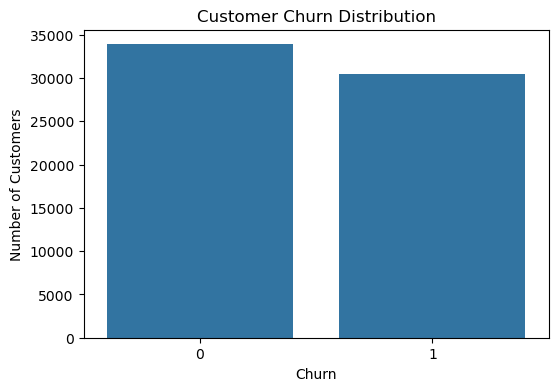

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [55]:
(df["Churn"].value_counts(normalize=True)*100).round(2)

Churn
0    52.63
1    47.37
Name: proportion, dtype: float64

## Observation

Approximately 52.63% of customers stayed with the company, while 47.37% of customers churned.

The target variable is nearly balanced, making it suitable for classification without requiring oversampling techniques at the initial stage.

## ```Gender vs Churn```

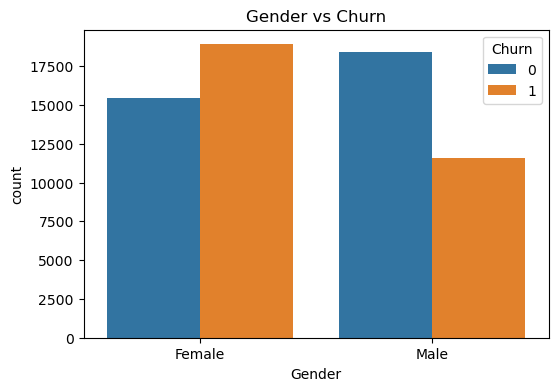

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

In [57]:
pd.crosstab(
    df["Gender"],
    df["Churn"],
    normalize="index"
)*100

Churn,0,1
Gender,,
Female,44.950950,55.049050
Male,61.420339,38.579661


## Observation

The churn rate of male and female customers appears to be similar.

Gender alone may not be a strong predictor of customer churn.

## Age Distribution 

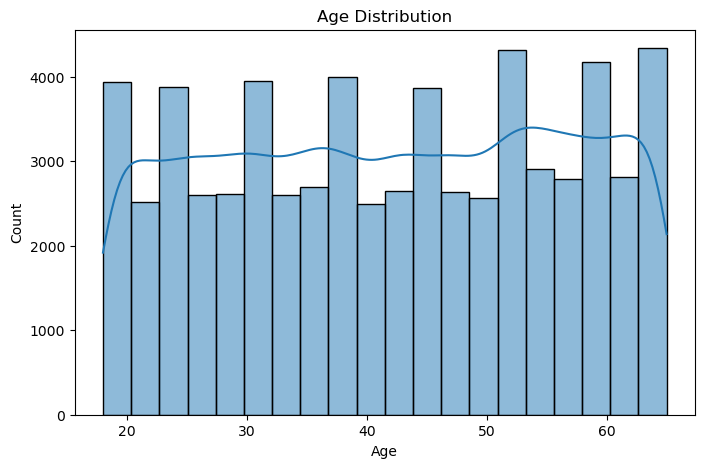

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

## Observation

The customer age distribution spans from 18 to 65 years, with a relatively balanced spread across different age groups.

## ```Age vs Churn```

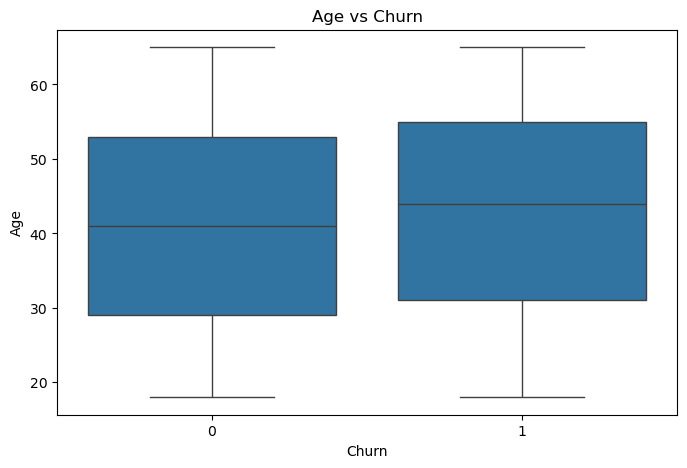

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Age"
)

plt.title("Age vs Churn")

plt.show()

In [60]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


## Subscription Type vs Churn

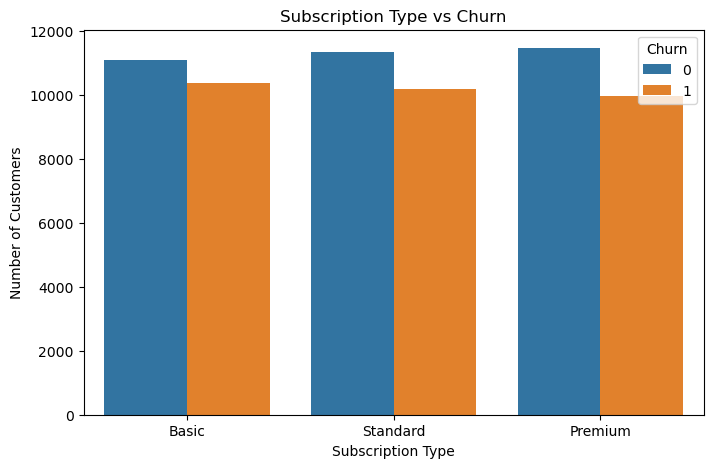

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Subscription Type",
    hue="Churn"
)

plt.title("Subscription Type vs Churn")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")

plt.show()

In [62]:
pd.crosstab(
    df["Subscription Type"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Subscription Type,,
Basic,51.722530,48.277470
Premium,53.503571,46.496429
Standard,52.669519,47.330481


## Contract Length vs Churn

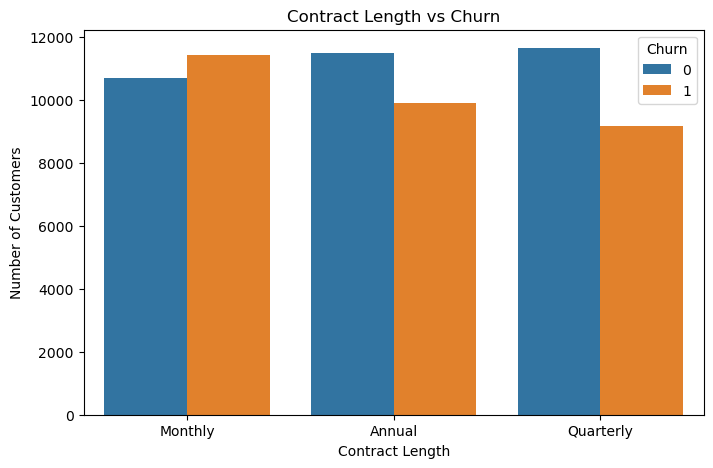

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract Length",
    hue="Churn"
)

plt.title("Contract Length vs Churn")
plt.xlabel("Contract Length")
plt.ylabel("Number of Customers")

plt.show()

In [64]:
pd.crosstab(
    df["Contract Length"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Contract Length,,
Annual,53.783279,46.216721
Monthly,48.391324,51.608676
Quarterly,55.951810,44.048190


## ```Tenure Distribution```

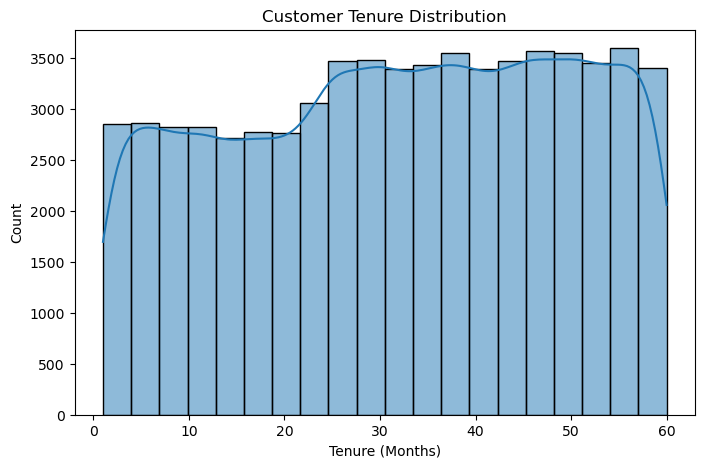

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Tenure"],
    bins=20,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")

plt.show()

### ```Tenure vs churn```

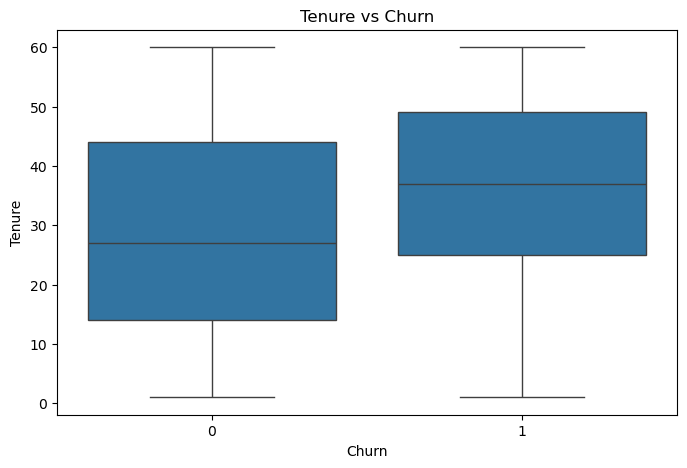

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure"
)

plt.title("Tenure vs Churn")

plt.show()

## Usage Frequency vs Churn

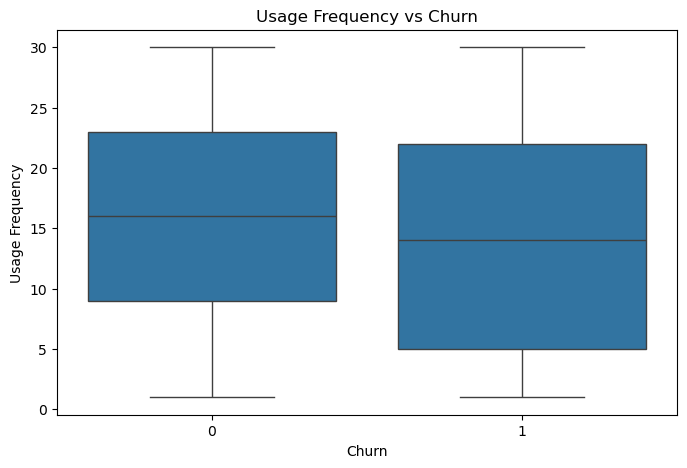

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Usage Frequency"
)

plt.title("Usage Frequency vs Churn")

plt.show()

## Support Calls vs Churn 

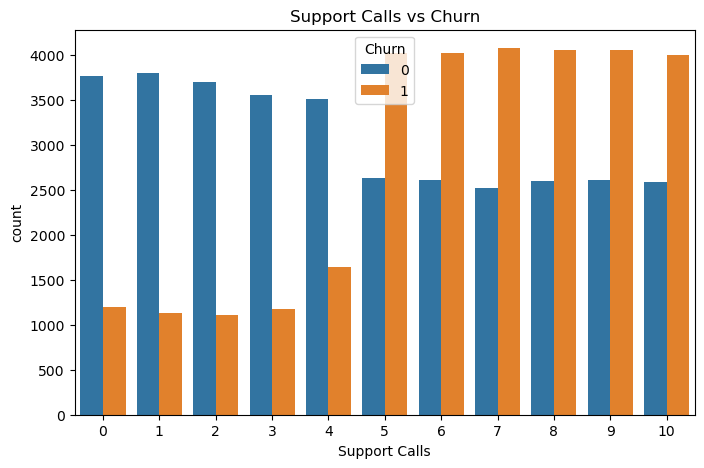

In [68]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Support Calls",
    hue="Churn"
)

plt.title("Support Calls vs Churn")

plt.show()

In [69]:
pd.crosstab(
    df["Support Calls"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Support Calls,,
0,75.780149,24.219851
1,77.115033,22.884967
2,76.849543,23.150457
3,75.164091,24.835909
4,68.162393,31.837607
5,39.537329,60.462671
6,39.388462,60.611538
7,38.217912,61.782088
8,39.043465,60.956535


## Payment Delay vs Churn

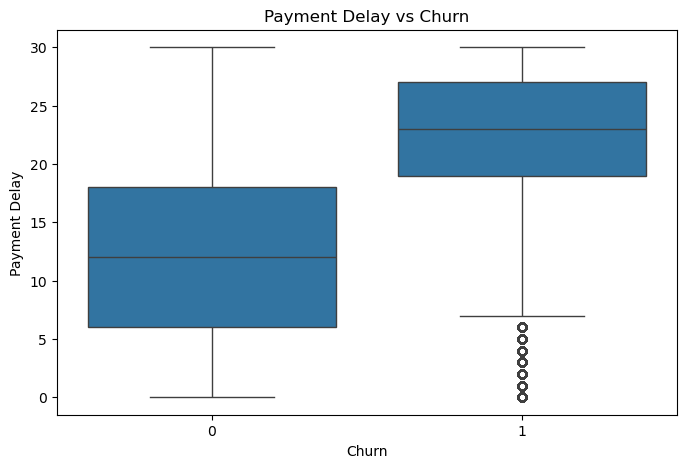

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Payment Delay"
)

plt.title("Payment Delay vs Churn")

plt.show()

## Total Spend vs Churn

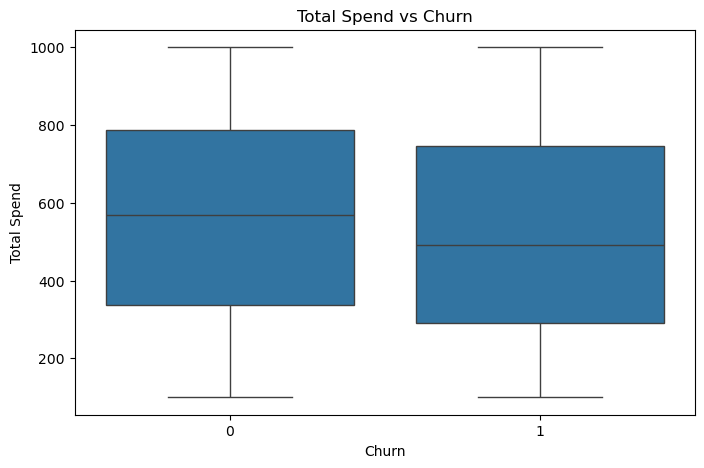

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Total Spend"
)

plt.title("Total Spend vs Churn")

plt.show()

## Correlation Heatmap

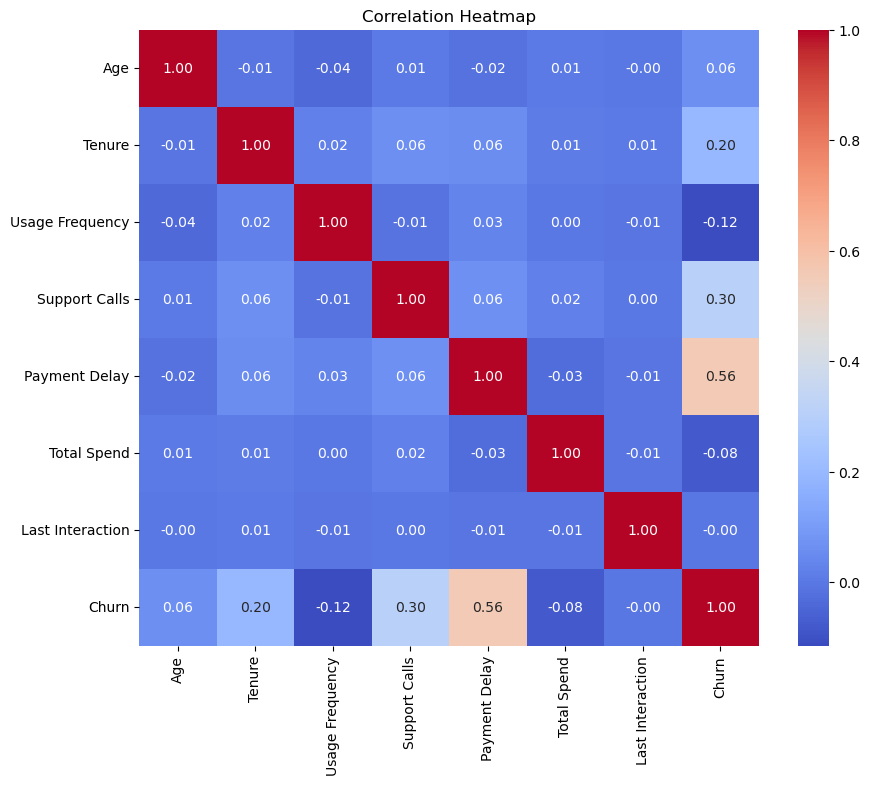

In [72]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The correlation heatmap shows that **Payment Delay** has the strongest positive correlation with **Customer Churn (0.56)** among all meaningful numerical features.

This indicates that customers who delay their payments are significantly more likely to churn.

Support Calls (0.30) and Tenure (0.20) also show positive relationships with churn, whereas Usage Frequency (-0.12) has a negative relationship, suggesting that customers who use the service more frequently are less likely to churn.

# EDA Summary

Key observations from the exploratory data analysis:

- The target variable is nearly balanced.
- Customer churn appears to vary across different subscription types and contract lengths.
- Customers with lower usage frequency are more likely to churn.
- Higher support calls may indicate customer dissatisfaction and increased churn risk.
- Payment delay shows a strong positive relationship with churn.
- Customer tenure plays an important role in customer retention.
- Total spend alone is not a strong indicator but may become useful when combined with other features.
- Correlation analysis suggests that Payment Delay and Support Calls are among the most influential numerical features for predicting churn.

## ```Separate Features and Target```

In [73]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (64374, 10)
y Shape : (64374,)


## Identify Numerical & Categorical Features

In [74]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [75]:
categorical_cols, numerical_cols

(Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object'),
 Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
        'Total Spend', 'Last Interaction'],
       dtype='object'))

## ```Encode Categorical Features```

## use one hot encoding

In [76]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,False,False,False,True,False
1,41,28,28,7,13,584,20,False,False,True,True,False
2,47,27,10,2,29,757,21,True,True,False,False,False
3,35,9,12,5,17,232,18,True,True,False,False,True
4,53,58,24,9,2,533,18,False,False,True,False,False


In [78]:
print("Shape after Encoding :", X.shape)

Shape after Encoding : (64374, 12)


## Encoding

Categorical features were converted into numerical format using One-Hot Encoding.

The `drop_first=True` parameter was used to avoid multicollinearity (dummy variable trap).

## Train Validation Split

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(51499, 12)
(12875, 12)


## Train Validation Split

The training dataset was divided into training and validation sets.

- Training Set: 80%
- Validation Set: 20%

Stratified sampling was used to preserve the original class distribution.

## ```5. Feature Scaling```

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

## Feature Scaling

Numerical features were standardized using StandardScaler.

The scaler was fitted only on the training data to avoid data leakage and then applied to the validation dataset.

# Preprocessing Summary

- Target variable separated.
- Numerical and categorical features identified.
- One-Hot Encoding applied to categorical variables.
- Training data split into training and validation sets.
- StandardScaler applied to numerical features.
- Dataset is now ready for machine learning models.

## Model Comparison

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_valid_scaled)
    print("" + "-"*50)
    print(f'{name:<22} : {accuracy_score(y_valid, y_pred):.4f}')
    
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    print(confusion_matrix(y_valid, y_pred))
    print(accuracy_score(y_valid, y_pred))
    print(classification_report(y_valid, y_pred))   

--------------------------------------------------
Logistic Regression    : 0.8271
[[5625 1151]
 [1075 5024]]
0.8271067961165048
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

--------------------------------------------------
KNN                    : 0.9106
[[5995  781]
 [ 370 5729]]
0.9106019417475728
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      6776
           1       0.88      0.94      0.91      6099

    accuracy                           0.91     12875
   macro avg       0.91      0.91      0.91     12875
weighted avg       0.91      0.91      0.91     12875

--------------------------------------------------
SVM                    : 0.9389
[[628

## Hyperparameter Tuning for Random Forest Classifier

In [92]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,          # 20 random combinations
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)
print("Best Parameters :", random_search.best_params_)
print("Best CV Score   :", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
Best CV Score   : 0.9986051614438981


In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_valid)

print("Accuracy :", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred))
print("Recall   :", recall_score(y_valid, y_pred))
print("F1 Score :", f1_score(y_valid, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, y_pred))

print("\nClassification Report")
print(classification_report(y_valid, y_pred))

Accuracy : 0.9986019417475728
Precision: 0.999015263417036
Recall   : 0.9980324643384161
F1 Score : 0.9985236220472441

Confusion Matrix
[[6770    6]
 [  12 6087]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



## Hyperparameter Tuning Results

RandomizedSearchCV was used to optimize the Random Forest classifier.

The tuned model achieved excellent performance on the validation dataset.

### Performance Metrics

- Accuracy  : 99.86%
- Precision : 99.90%
- Recall    : 99.80%
- F1-Score  : 99.85%

The confusion matrix indicates that the model made only 18 incorrect predictions out of 12,875 validation samples, demonstrating outstanding classification performance.

                       Feature  Importance
4                Payment Delay    0.445973
3                Support Calls    0.165787
1                       Tenure    0.108511
2              Usage Frequency    0.081994
7                  Gender_Male    0.075532
5                  Total Spend    0.044017
0                          Age    0.037533
10     Contract Length_Monthly    0.026286
11   Contract Length_Quarterly    0.006319
6             Last Interaction    0.005508
8    Subscription Type_Premium    0.001324
9   Subscription Type_Standard    0.001215


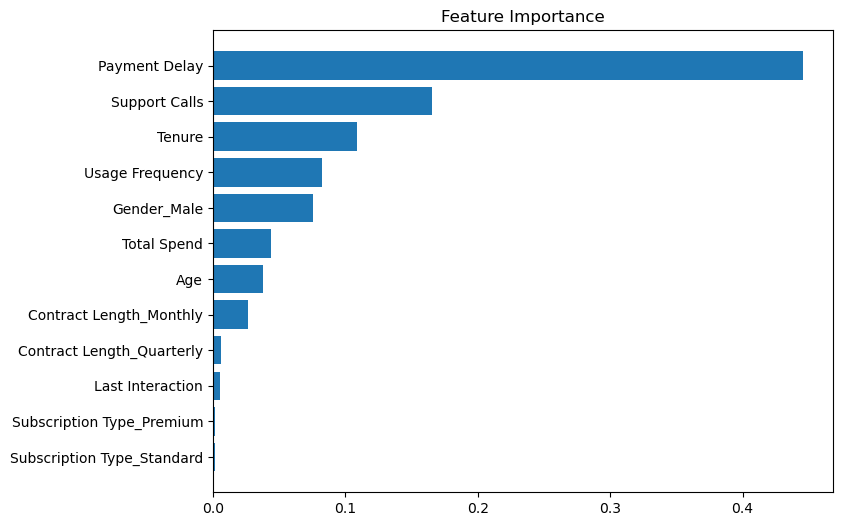

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()